## Visualize the 3 fidelities together

In [1]:
# ## Load and aggregate the three normalized metrics

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/moz_vam")

MARGINAL_PATH = FIDELITY_DIR / "emd_gen_true_normalized.csv"
BIVARIATE_PATH = FIDELITY_DIR / "corrdiff_gen_true_normalized.csv"
JOINT_PATH = FIDELITY_DIR / "joint_emd_gen_true_normalized.csv"

marginal_df = pd.read_csv(MARGINAL_PATH)
bivariate_df = pd.read_csv(BIVARIATE_PATH)
joint_df = pd.read_csv(JOINT_PATH)

print("marginal_df:", marginal_df.shape)
print("bivariate_df:", bivariate_df.shape)
print("joint_df:", joint_df.shape)

display(marginal_df.head())
display(bivariate_df.head())
display(joint_df.head())

marginal_df: (1085, 10)
bivariate_df: (2170, 14)
joint_df: (217, 11)


,model,seed,adm1,variable,emd_distance,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Cabo Delgado,FCS,4.397993,14.041273,13.039803,-1.001471,9.629119,1.000000
1,cNF,1,Cabo Delgado,rCSI,1.040229,1.517364,5.885722,4.368358,-0.109225,0.000000
2,cNF,1,Cabo Delgado,FGVitA,0.823668,0.399282,3.430691,3.031409,0.139996,0.139996
3,cNF,1,Cabo Delgado,FGProtein,1.112104,2.299938,3.121360,0.821423,-1.446070,0.000000
4,cNF,1,Cabo Delgado,FGHIron,0.407815,0.164989,1.927950,1.762961,0.137737,0.137737


,model,seed,adm1,var1,var2,pair,corr_real,corr_syn,corrdiff,corrdiff_ub,corrdiff_lb,denom,corrdiff_norm_raw,corrdiff_norm
0,cNF,1,Cabo Delgado,FCS,rCSI,FCS__rCSI,-0.141092,-0.224114,0.083022,0.040750,0.129024,0.088274,0.478878,0.478878
1,cNF,1,Cabo Delgado,FCS,FGVitA,FCS__FGVitA,0.462864,0.587260,0.124396,0.006419,0.442892,0.436473,0.270298,0.270298
2,cNF,1,Cabo Delgado,FCS,FGProtein,FCS__FGProtein,0.825634,0.868591,0.042957,0.019483,0.807702,0.788219,0.029782,0.029782
3,cNF,1,Cabo Delgado,FCS,FGHIron,FCS__FGHIron,0.579359,0.569523,0.009837,0.028583,0.609919,0.581336,-0.032247,0.000000
4,cNF,1,Cabo Delgado,rCSI,FGVitA,rCSI__FGVitA,-0.030746,-0.124448,0.093702,0.035311,0.034166,-0.001144,-51.020407,0.000000


,model,seed,adm1,joint_emd,n_real,n_syn,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Cabo Delgado,0.780269,1389,1389,0.274353,1.309635,1.035282,0.488674,0.488674
1,cNF,1,Gaza,1.196688,447,447,0.332765,2.181733,1.848969,0.467246,0.467246
2,cNF,1,Inhambane,1.066455,426,426,0.339815,2.086905,1.747089,0.415915,0.415915
3,cNF,1,Manica,1.556574,388,388,0.310296,2.312537,2.002241,0.622441,0.622441
4,cNF,1,Maputo Cidade,0.637184,445,445,0.314621,1.876435,1.561813,0.206531,0.206531


In [3]:
# Average marginal over variables for each (model, seed, adm1)
marginal_avg = (
    marginal_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        marginal_norm=("emd_norm", "mean")
    )
)

# Average bivariate over pairs for each (model, seed, adm1)
bivariate_avg = (
    bivariate_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        bivariate_norm=("corrdiff_norm", "mean")
    )
)

# Joint is already one value per (model, seed, adm1)
joint_avg = (
    joint_df[["model", "seed", "adm1", "emd_norm"]]
    .rename(columns={"emd_norm": "joint_norm"})
    .copy()
)

display(marginal_avg.head())
display(bivariate_avg.head())
display(joint_avg.head())

,model,seed,adm1,marginal_norm
0,CTGAN,1,Cabo Delgado,0.290382
1,CTGAN,1,Gaza,0.022451
2,CTGAN,1,Inhambane,0.140624
3,CTGAN,1,Manica,0.103298
4,CTGAN,1,Maputo Cidade,0.249072


,model,seed,adm1,bivariate_norm
0,CTGAN,1,Cabo Delgado,0.517634
1,CTGAN,1,Gaza,0.160174
2,CTGAN,1,Inhambane,0.394137
3,CTGAN,1,Manica,0.193459
4,CTGAN,1,Maputo Cidade,0.421571


,model,seed,adm1,joint_norm
0,cNF,1,Cabo Delgado,0.488674
1,cNF,1,Gaza,0.467246
2,cNF,1,Inhambane,0.415915
3,cNF,1,Manica,0.622441
4,cNF,1,Maputo Cidade,0.206531


In [4]:
# Merge the 3 metrics so each row is one (model, seed, adm1)
metrics_3way = (
    marginal_avg
    .merge(bivariate_avg, on=["model", "seed", "adm1"], how="inner")
    .merge(joint_avg, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("metrics_3way shape:", metrics_3way.shape)
display(metrics_3way.head())

metrics_3way shape: (217, 6)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Cabo Delgado,0.290382,0.517634,0.822692
1,CTGAN,1,Gaza,0.022451,0.160174,0.381105
2,CTGAN,1,Inhambane,0.140624,0.394137,0.471917
3,CTGAN,1,Manica,0.103298,0.193459,0.406874
4,CTGAN,1,Maputo Cidade,0.249072,0.421571,0.586014


In [5]:
# Optional: save merged table
OUT_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
metrics_3way.to_csv(OUT_PATH, index=False)
print(f"Saved merged table to: {OUT_PATH}")

Saved merged table to: /data/shared/fsibilla/clean_code/Q0/fidelity/moz_vam/merged_marginal_bivariate_joint_normalized.csv


In [6]:
# ## Prepare radar-plot summary
#
# We want:
# - for each model and seed: average across adm1
# - then across seeds: mean
# - and std based on the adm1-level variability after seed averaging

METRIC_COLS = ["marginal_norm", "bivariate_norm", "joint_norm"]

# Mean over adm1 within each seed
seed_level = (
    metrics_3way
    .groupby(["model", "seed"], as_index=False)[METRIC_COLS]
    .mean()
)

display(seed_level.head())

,model,seed,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,0.129661,0.295140,0.561512
1,CTGAN,2,0.104742,0.221357,0.483641
2,CTGAN,3,0.130924,0.263629,0.535786
3,CTGAN,4,0.133343,0.243581,0.552468
4,CTGAN,5,0.115920,0.246190,0.481032


In [7]:
# Mean and std across seeds for the central line
model_mean_std = (
    seed_level
    .groupby("model", as_index=False)
    .agg(
        marginal_mean=("marginal_norm", "mean"),
        marginal_std_seed=("marginal_norm", "std"),
        bivariate_mean=("bivariate_norm", "mean"),
        bivariate_std_seed=("bivariate_norm", "std"),
        joint_mean=("joint_norm", "mean"),
        joint_std_seed=("joint_norm", "std"),
    )
)

model_mean_std = model_mean_std.fillna(0.0)
display(model_mean_std)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed
0,CTGAN,0.122918,0.012223,0.253979,0.027479,0.522888,0.038162
1,NF,0.064883,0.010103,0.139621,0.030682,0.285473,0.033216
2,TVAE,0.457712,0.091568,0.314682,0.038633,0.753929,0.063777
3,cNF,0.131185,0.006539,0.222916,0.018152,0.403710,0.020186


In [8]:
# Std over adm1:
# first average across seeds for each (model, adm1), then compute std across adm1

adm1_level = (
    metrics_3way
    .groupby(["model", "adm1"], as_index=False)[METRIC_COLS]
    .mean()
)

model_adm1_std = (
    adm1_level
    .groupby("model", as_index=False)
    .agg(
        marginal_std_adm1=("marginal_norm", "std"),
        bivariate_std_adm1=("bivariate_norm", "std"),
        joint_std_adm1=("joint_norm", "std"),
    )
)

model_adm1_std = model_adm1_std.fillna(0.0)
display(model_adm1_std)

,model,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.077394,0.072937,0.125775
1,NF,0.055334,0.057104,0.080078
2,TVAE,0.193330,0.140799,0.218690
3,cNF,0.086219,0.082903,0.100737


In [9]:
# Final table for plotting
radar_df = (
    model_mean_std
    .merge(model_adm1_std, on="model", how="left")
    .fillna(0.0)
)

display(radar_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.122918,0.012223,0.253979,0.027479,0.522888,0.038162,0.077394,0.072937,0.125775
1,NF,0.064883,0.010103,0.139621,0.030682,0.285473,0.033216,0.055334,0.057104,0.080078
2,TVAE,0.457712,0.091568,0.314682,0.038633,0.753929,0.063777,0.193330,0.140799,0.218690
3,cNF,0.131185,0.006539,0.222916,0.018152,0.403710,0.020186,0.086219,0.082903,0.100737


In [10]:
# ## Spider / radar plot

MODEL_ORDER = ["cNF", #"NF", 
"TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in radar_df["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

AXES_LABELS = ["Marginal", "Bivariate", "Joint"]
N_AXES = len(AXES_LABELS)

angles = np.linspace(0, 2 * np.pi, N_AXES, endpoint=False).tolist()
angles += angles[:1]  # close polygon

In [11]:
def close_vals(vals):
    vals = list(vals)
    return vals + vals[:1]

In [12]:
# Convert normalized errors into normalized fidelity scores
radar_score_df = radar_df.copy()

for col in [
    "marginal_mean", "bivariate_mean", "joint_mean",
]:
    radar_score_df[col] = 1.0 - radar_score_df[col]

display(radar_score_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.877082,0.012223,0.746021,0.027479,0.477112,0.038162,0.077394,0.072937,0.125775
1,NF,0.935117,0.010103,0.860379,0.030682,0.714527,0.033216,0.055334,0.057104,0.080078
2,TVAE,0.542288,0.091568,0.685318,0.038633,0.246071,0.063777,0.193330,0.140799,0.218690
3,cNF,0.868815,0.006539,0.777084,0.018152,0.596290,0.020186,0.086219,0.082903,0.100737


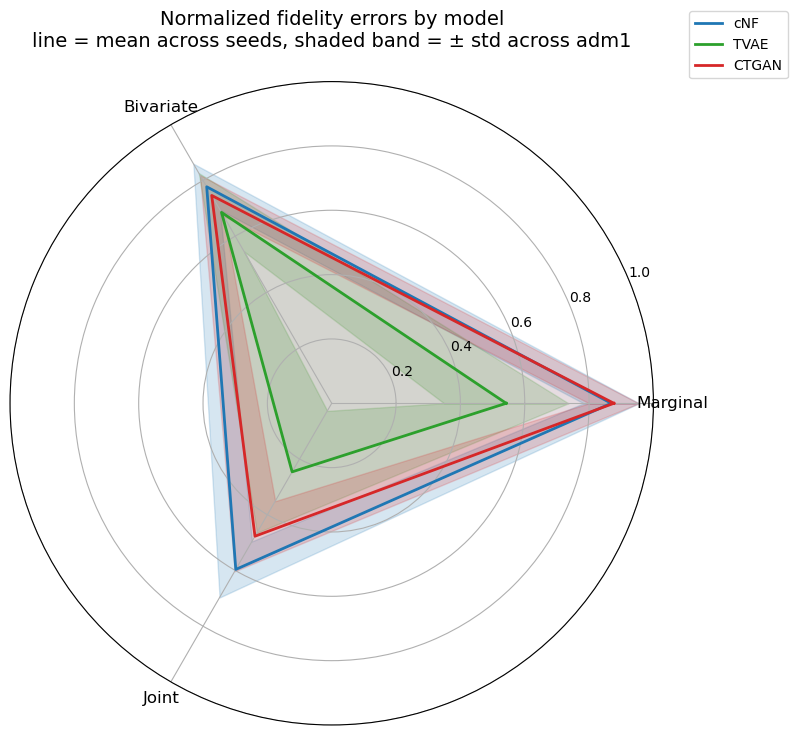

In [13]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model in MODEL_ORDER:
    row = radar_score_df.loc[radar_score_df["model"] == model]
    if row.empty:
        continue
    row = row.iloc[0]

    means = [
        row["marginal_mean"],
        row["bivariate_mean"],
        row["joint_mean"],
    ]

    stds_adm1 = [
        row["marginal_std_adm1"],
        row["bivariate_std_adm1"],
        row["joint_std_adm1"],
    ]

    lower = np.clip(np.array(means) - np.array(stds_adm1), 0, 1)
    upper = np.clip(np.array(means) + np.array(stds_adm1), 0, 1)

    means_c = close_vals(means)
    lower_c = close_vals(lower)
    upper_c = close_vals(upper)

    color = MODEL_COLORS.get(model, "gray")

    ax.plot(
        angles,
        means_c,
        color=color,
        linewidth=2,
        label=model,
    )

    ax.fill(
        angles,
        means_c,
        color=color,
        alpha=0.10,
    )

    ax.fill_between(
        angles,
        lower_c,
        upper_c,
        color=color,
        alpha=0.18,
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(AXES_LABELS, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])
ax.set_title(
    "Normalized fidelity errors by model\nline = mean across seeds, shaded band = ± std across adm1",
    pad=25,
    fontsize=14
)
ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1.12))

plt.tight_layout()
plt.show()

## Look at originality too

In [14]:
# ## Load fidelity + recall

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/moz_vam")
RECALL_DIR = Path("/data/shared/fsibilla/clean_code/Q0/recall/moz_vam")

FIDELITY_3WAY_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
RECALL_PATH = RECALL_DIR / "recall_gen_true_by_adm1.csv"

fidelity_3way = pd.read_csv(FIDELITY_3WAY_PATH)
recall_df = pd.read_csv(RECALL_PATH)

print("fidelity_3way:", fidelity_3way.shape)
print("recall_df:", recall_df.shape)

display(fidelity_3way.head())
display(recall_df.head())

fidelity_3way: (217, 6)
recall_df: (217, 8)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Cabo Delgado,0.290382,0.517634,0.822692
1,CTGAN,1,Gaza,0.022451,0.160174,0.381105
2,CTGAN,1,Inhambane,0.140624,0.394137,0.471917
3,CTGAN,1,Manica,0.103298,0.193459,0.406874
4,CTGAN,1,Maputo Cidade,0.249072,0.421571,0.586014


,model,seed,adm1,recall,matched_real,n_real,n_syn,radius
0,cNF,1,Cabo Delgado,0.734341,1020,1389,1389,0.5
1,cNF,1,Gaza,0.704698,315,447,447,0.5
2,cNF,1,Inhambane,0.622066,265,426,426,0.5
3,cNF,1,Manica,0.721649,280,388,388,0.5
4,cNF,1,Maputo Cidade,0.629213,280,445,445,0.5


In [16]:
# Average the 3 fidelity metrics into one fidelity score (still an error, so lower is better)
fidelity_3way = fidelity_3way.copy()

fidelity_3way["fidelity_mean"] = fidelity_3way[
    ["marginal_norm", "bivariate_norm", "joint_norm"]
].mean(axis=1)

display(fidelity_3way.head())

,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm,fidelity_mean
0,CTGAN,1,Cabo Delgado,0.290382,0.517634,0.822692,0.543569
1,CTGAN,1,Gaza,0.022451,0.160174,0.381105,0.187910
2,CTGAN,1,Inhambane,0.140624,0.394137,0.471917,0.335559
3,CTGAN,1,Manica,0.103298,0.193459,0.406874,0.234543
4,CTGAN,1,Maputo Cidade,0.249072,0.421571,0.586014,0.418886


In [17]:
# Keep only the columns needed for the merge
fidelity_for_merge = fidelity_3way[
    ["model", "seed", "adm1", "fidelity_mean"]
].copy()

recall_for_merge = recall_df[
    ["model", "seed", "adm1", "recall"]
].copy()

plot_source = (
    fidelity_for_merge
    .merge(recall_for_merge, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("plot_source shape:", plot_source.shape)
display(plot_source.head())

plot_source shape: (217, 5)


,model,seed,adm1,fidelity_mean,recall
0,CTGAN,1,Cabo Delgado,0.543569,0.455724
1,CTGAN,1,Gaza,0.187910,0.588367
2,CTGAN,1,Inhambane,0.335559,0.481221
3,CTGAN,1,Manica,0.234543,0.587629
4,CTGAN,1,Maputo Cidade,0.418886,0.433708


In [18]:
# One scatter point per model with x/y std dev error bars
model_summary = (
    plot_source
    .groupby("model", as_index=False)
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        fidelity_mean=("fidelity_mean", "mean"),
        fidelity_std=("fidelity_mean", "std"),
        n_rows=("recall", "count"),
    )
)

model_summary["recall_std"] = model_summary["recall_std"].fillna(0.0)
model_summary["fidelity_std"] = model_summary["fidelity_std"].fillna(0.0)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,CTGAN,0.491123,0.075791,0.299928,0.088259,55
1,NF,0.658170,0.104305,0.163326,0.068630,55
2,TVAE,0.362125,0.238980,0.517870,0.207989,52
3,cNF,0.614890,0.098502,0.252603,0.073605,55


In [19]:
MODEL_ORDER = ["cNF", #"NF",
 "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in model_summary["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    #"NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

model_summary = (
    model_summary
    .set_index("model")
    .loc[MODEL_ORDER]
    .reset_index()
)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,cNF,0.614890,0.098502,0.252603,0.073605,55
1,TVAE,0.362125,0.238980,0.517870,0.207989,52
2,CTGAN,0.491123,0.075791,0.299928,0.088259,55


In [20]:
model_summary_plot = model_summary.copy()
model_summary_plot["fidelity_score"] = 1.0 - model_summary_plot["fidelity_mean"]

display(model_summary_plot)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows,fidelity_score
0,cNF,0.614890,0.098502,0.252603,0.073605,55,0.747397
1,TVAE,0.362125,0.238980,0.517870,0.207989,52,0.482130
2,CTGAN,0.491123,0.075791,0.299928,0.088259,55,0.700072


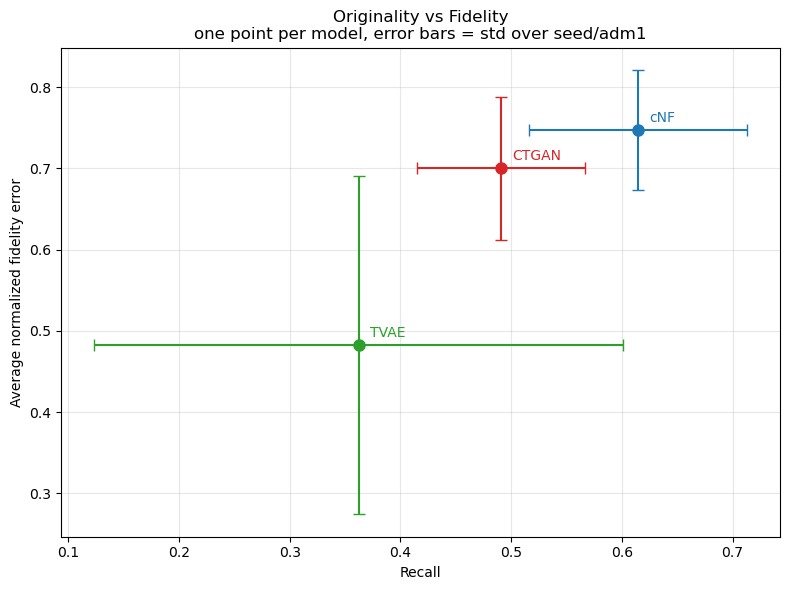

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in model_summary_plot.iterrows():
    model = row["model"]
    x = row["recall_mean"]
    y = row["fidelity_score"]
    xerr = row["recall_std"]
    yerr = row["fidelity_std"]
    color = MODEL_COLORS.get(model, "gray")

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        capsize=4,
        markersize=8,
        color=color,
        ecolor=color,
        elinewidth=1.5,
        label=model,
    )

    ax.text(
        x + 0.01,
        y + 0.01,
        model,
        fontsize=10,
        color=color,
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Average normalized fidelity error")
ax.set_title("Originality vs Fidelity\none point per model, error bars = std over seed/adm1")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()